# Cordillera Huayhuash — Descarga de Datos

**Proyecto**: Pan-Andean GLOF Susceptibility Assessment  
**Área**: `cordillera_huayhuash`  
**Datos**: DEM NASADEM 30m + Sentinel-2 L2A (2017-2025)  
**Fuente**: Microsoft Planetary Computer STAC API  

## Descripción

Descarga DEM (NASADEM 30m) y Sentinel-2 L2A multitemporal (2017-2025)
para la Cordillera Huayhuash. Usa src/download.py que contiene la corrección
del bug de proyección WGS-84 → UTM.

## Instrucciones

1. Ejecutar **Celda 1** (importaciones)
2. Ejecutar **Celda 2** (descarga)
3. Verificar el resumen al final


In [1]:
# Librerías estándar
import sys
import os
from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configurar ruta del proyecto (funciona tanto desde notebooks/ como desde la raíz)
project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(project_root))

# Importar módulo de descarga centralizado (src/download.py)
import src.download
from src.download import download_study_area_data
from config_expanded_study_areas import EXPANDED_STUDY_AREAS

# --- CRÍTICO: Forzar recarga del módulo para garantizar uso de versión corregida ---
import importlib
importlib.reload(src.download)
from src.download import download_study_area_data
# --------------------------------------------------------------------------------

print(f"Proyecto raíz : {project_root}")
print(f"Inicio        : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("Importaciones OK (Módulo src.download recargado)")

Proyecto raíz : /home/andre/Documents/GLOF_Andes_Project-Paper
Inicio        : 2026-02-19 09:52:33
Importaciones OK (Módulo src.download recargado)


Usando TODOS los años disponibles: 2017-2025 (9 años)
  GLOF Project >> CORDILLERA HUAYHUASH, ANCASH-LIMA BORDER
  Bbox: [-76.95, -10.35, -76.75, -10.05]  |  EPSG:32718
  ~80 lagunas  |  3 GLOFs documentados
  Serie temporal: 2017–2025 (9 años)  |  Bandas: B02 B03 B04 B08 B11 B12

[DEM] NASADEM 30m
  [ok] NASADEM_HGT_s11w077  (1.2 MB, existente)
  Total: 1 tile(s)

[Sentinel-2 L2A] Temporada seca: meses [6, 7, 8]  |  nubosidad < 15%
  [ok] 2017  2017-06-20  cloud:0.8%  [B02 B03 B04 B08 B11 B12]  105.9 MB  (existentes)
  [ok] 2018  2018-06-23  cloud:0.4%  [B02 B03 B04 B08 B11 B12]  69.9 MB  (existentes)
  [ok] 2019  2019-06-08  cloud:0.1%  [B02 B03 B04 B08 B11 B12]  66.8 MB  (existentes)
  [ok] 2020  2020-06-09  cloud:0.0%  [B02 B03 B04 B08 B11 B12]  472.7 MB  (existentes)
  [ok] 2021  2021-07-24  cloud:0.0%  [B02 B03 B04 B08 B11 B12]  473.2 MB  (existentes)
  [ok] 2022  2022-08-26  cloud:0.0%  [B02 B03 B04 B08 B11 B12]  58.8 MB  (existentes)
  [ok] 2023  2023-08-21  cloud:0.0%  [B02 B0

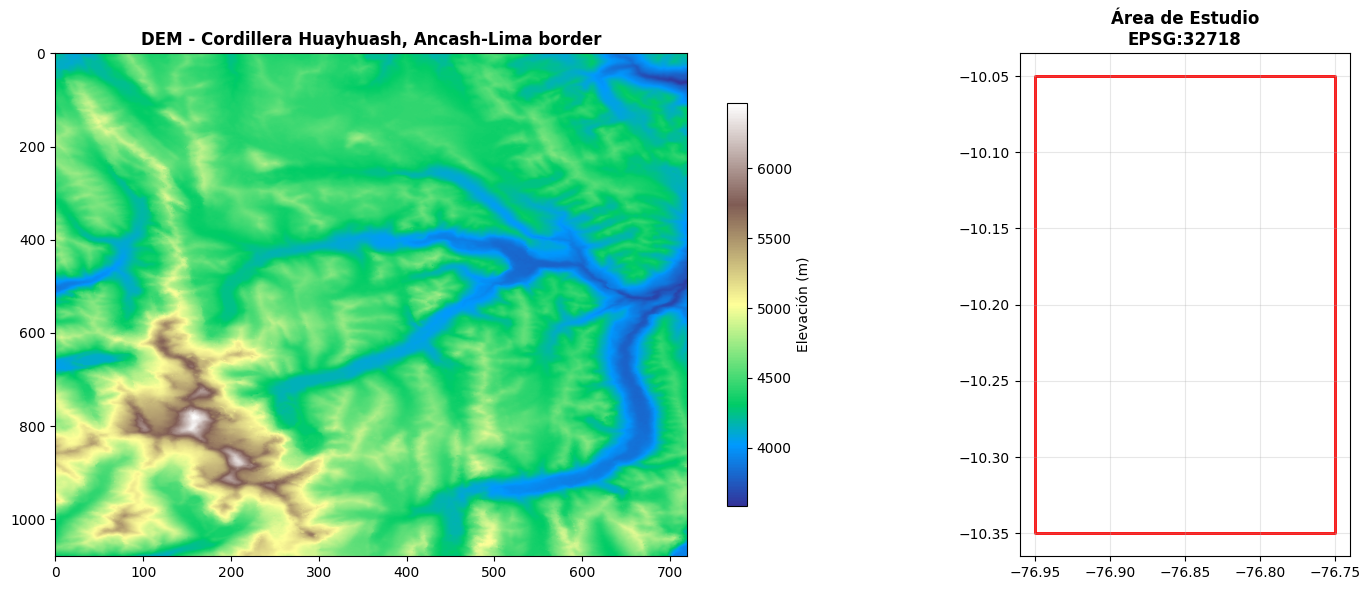

  Visualización guardada: /home/andre/Documents/GLOF_Andes_Project-Paper/figures/downloads/download_cordillera_huayhuash.png
  Metadatos: /home/andre/Documents/GLOF_Andes_Project-Paper/data/raw/metadata_cordillera_huayhuash.json
DESCARGA COMPLETADA EXITOSAMENTE

DESCARGA COMPLETADA EXITOSAMENTE
  Tiles DEM       : 1
  Años Sentinel-2 : 9 [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
  Tamaño total    : 1.32 GB
  Metadatos       : /home/andre/Documents/GLOF_Andes_Project-Paper/data/raw/metadata_cordillera_huayhuash.json


In [2]:
# Configuración del área de estudio
area_name = 'cordillera_huayhuash'

# Ejecutar pipeline de descarga completo
# years=None → usa TODOS los años disponibles: 2017-2025 (9 años)
results = download_study_area_data(
    area_name=area_name,
    years=None,           # Todos los años: 2017-2025
    months=[6, 7, 8],    # Temporada seca (invierno austral)
    sentinel_bands=['B02', 'B03', 'B04', 'B08', 'B11', 'B12'],
    max_cloud_cover=15,  # Máximo 15% de nubosidad
    visualize=True,
    save_metadata=True,
)

# Verificar resultado
if results['success']:
    print("\n" + "=" * 80)
    print("DESCARGA COMPLETADA EXITOSAMENTE")
    print("=" * 80)
    print(f"  Tiles DEM       : {results['dem_tiles']}")
    print(f"  Años Sentinel-2 : {len(results['sentinel_years'])} {results['sentinel_years']}")
    print(f"  Tamaño total    : {results['total_size_gb']:.2f} GB")
    print(f"  Metadatos       : {results['metadata_path']}")
else:
    print("\n[ERROR] La descarga no se completó correctamente.")
    print("Revisa los mensajes de error anteriores.")
